# Day 7 – Risk Optimization & Position Sizing (EURUSD)

## Objective
Improve strategy performance by controlling risk through dynamic position sizing and volatility targeting.

## Goal
Enhance risk-adjusted returns while reducing drawdowns.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#Create Output Folders
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [3]:
#Load Dataset
file_path = r"C:\Users\THIS PC\Desktop\quant-finance-portfolio\day-01-market-data-analysis\data\eurusd_daily_raw.csv"
df = pd.read_csv(file_path, index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [4]:
# Base Strategy (SMA)
df["SMA_20"] = df["close"].rolling(20).mean()
df["SMA_50"] = df["close"].rolling(50).mean()
df["signal"] = np.where(df["SMA_20"] > df["SMA_50"], 1, 0)
df["position"] = df["signal"].shift(1)


In [5]:
# Calculate Rolling Volatility
df["rolling_vol"] = df["simple_return"].rolling(20).std()

In [6]:
# Volatility Targeting (CORE STEP)
#Set target risk: 
target_vol = 0.01
#Create position size:
df["position_size"] = target_vol / df["rolling_vol"]
#This means:High volatility → smaller position, Low volatility → larger position
# Cap Position Size (VERY IMPORTANT)
df["position_size"] = df["position_size"].clip(upper=3)


In [7]:
# Adjusted Strategy Returns
df["strategy_return"] = df["position"] * df["simple_return"] * df["position_size"]
# Equity Curve
df["equity"] = (1 + df["strategy_return"]).cumprod()
df["buy_hold"] = (1 + df["simple_return"]).cumprod()

In [8]:
vol_threshold = df["rolling_vol"].median()

df["vol_regime"] = np.where(
    df["rolling_vol"] > vol_threshold,
    "High Volatility",
    "Low Volatility"
)
#Summary Performance
regime_summary = df.groupby("vol_regime")["strategy_return"].agg(["mean", "std", "count"])
regime_summary



,mean,std,count
vol_regime,,,
High Volatility,0.000008,0.006723,2490
Low Volatility,0.000124,0.006908,2490


In [9]:
#Annualizing the mean and std
regime_summary = df.groupby("vol_regime")["strategy_return"].agg(
    Annual_Return=lambda x: x.mean() * 252,
    Annual_Volatility=lambda x: x.std() * np.sqrt(252),
    Observations="count"
)

regime_summary

,Annual_Return,Annual_Volatility,Observations
vol_regime,,,
High Volatility,0.001946,0.106720,2490
Low Volatility,0.031127,0.109667,2490


In [10]:
#Save regime_summary
regime_summary.to_csv("outputs/tables/day07_regime_summary.csv")

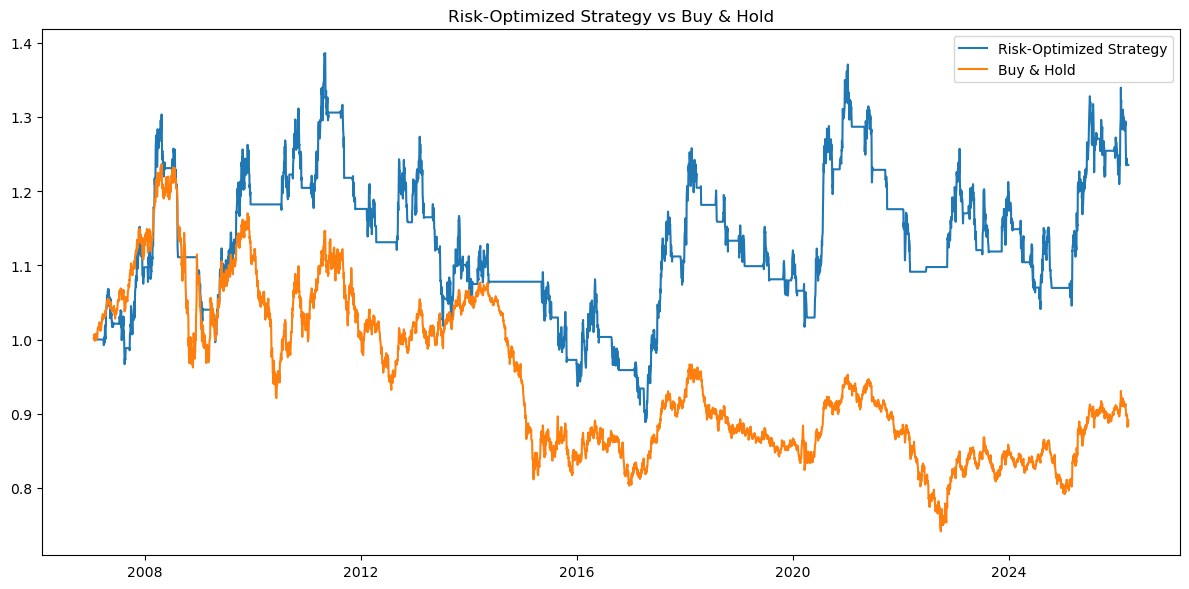

,Metric,Value
0,Return,0.016537
1,Volatility,0.108196
2,Sharpe,0.152838
3,Max Drawdown,-0.358673


In [11]:
# Plot Performance
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["equity"], label="Risk-Optimized Strategy")
plt.plot(df.index, df["buy_hold"], label="Buy & Hold")

plt.title("Risk-Optimized Strategy vs Buy & Hold")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/day07_equity.png")
plt.show()
#  Drawdown
rolling_max = df["equity"].cummax()
df["drawdown"] = (df["equity"] - rolling_max) / rolling_max
# Step 13 — Metrics
annual_return = df["strategy_return"].mean() * 252
annual_vol = df["strategy_return"].std() * np.sqrt(252)
sharpe = annual_return / annual_vol
max_dd = df["drawdown"].min()

metrics = pd.DataFrame({
    "Metric": ["Return", "Volatility", "Sharpe", "Max Drawdown"],
    "Value": [annual_return, annual_vol, sharpe, max_dd]
})

metrics

In [12]:
#Save File
metrics.to_csv("outputs/tables/day07_metrics.csv", index=False)
df.to_csv("outputs/tables/day07_data.csv")

## Analyst Interpretation

This analysis focuses on how the improved strategy performs when risk is actively managed.

Looking at the results, each metric tells a different part of the story:

- **Return (0.0165)**  
This means the strategy generated approximately a 1.65% return over the period. While this is a positive outcome, it is relatively modest, suggesting that the strategy is not aggressively chasing profits but instead focusing on controlled growth.

- **Volatility (0.1082)**  
Volatility reflects how much the strategy’s returns fluctuate over time. A value of about 10.8% indicates that the strategy experiences noticeable ups and downs. This means the performance is not perfectly smooth and there are periods of instability.

- **Sharpe Ratio (0.1528)**  
The Sharpe ratio measures how efficiently the strategy generates returns relative to the risk taken. A value of 0.15 is relatively low, indicating that the return achieved is not very high compared to the level of risk. In simple terms, the strategy is taking on risk but not being strongly rewarded for it.

- **Max Drawdown (-0.3587)**  
This is one of the most important metrics. It shows that at some point, the strategy lost about 35.9% of its value from a peak. This highlights that even with risk control measures, the strategy still experienced a significant decline, which could be difficult for a trader to tolerate.

---

## Overall Interpretation

The results show that while the strategy introduces better risk control through position sizing, it still faces challenges.

- The returns are positive but relatively low  
- Risk (volatility and drawdown) remains significant  
- The strategy is not yet efficient in converting risk into strong returns  

This suggests that:

👉 Risk control alone is not enough  
👉 The quality of the trading signals also needs improvement  

---

## Key Insight

This project highlights an important lesson in trading:

> Reducing risk does not automatically increase performance.

A well-performing strategy must strike a balance between:
- generating returns  
- controlling risk  
- maintaining consistency  

---

## Conclusion

The strategy has taken a step forward by incorporating risk management, but it is not yet optimal. Further improvements—such as better signal filtering, strategy combination, or parameter tuning—are needed to achieve stronger and more consistent results.